# Plots

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
import os

In [2]:
## Read in IRWin Station Data
from pathlib import Path, PurePath
SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')

PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

In [3]:
# MODELED
save_dir = 'modeled-station-data'

s3_dsw3 = xr.open_dataset(os.path.join(save_dir, 's3_dsw3.nc'))
s3_dsw1 = xr.open_dataset(os.path.join(save_dir, 's3_dsw1.nc'))
s3_dsw30 = xr.open_dataset(os.path.join(save_dir, 's3_dsw30.nc'))
s3_k = xr.open_dataset(os.path.join(save_dir, 's3_k.nc'))
s3_ghi = xr.open_dataset(os.path.join(save_dir, 's3_ghi.nc'))

m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
m1_dsw1 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw1.nc'))
m1_dsw30 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw30.nc'))
m1_k = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))
m1_ghi = xr.open_dataset(os.path.join(save_dir, 'm1_ghi.nc'))

irwin_dsw3 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw3.nc'))
irwin_dsw30 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw30.nc'))
irwin_dsw1 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw1.nc'))
irwin_k = xr.open_dataset(os.path.join(save_dir, 'irwin_k.nc'))
irwin_ghi = xr.open_dataset(os.path.join(save_dir, 'irwin_ghi.nc'))

sos_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw3.nc'))
sos_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw1.nc'))
sos_dsw30 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw30.nc'))
sos_k = xr.open_dataset(os.path.join(save_dir, 'sos_k.nc'))
sos_ghi = xr.open_dataset(os.path.join(save_dir, 'sos_ghi.nc'))

# # # # # # #

# STATION DATA
save_dir = 'station-data'

# SAIL M1 QCRAD LONG
subset_sw_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_sw.nc'))
subset_dif_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_diff.nc'))
subset_dir_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dir.nc'))
subset_best_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_best_sw.nc'))
subset_zenith_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_zen.nc'))
sub_dirh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dirh.nc'))
sub_difh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_difh_xx.nc'))

# SAIL M1 & S3
m1_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sw.nc'))
s3_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 's3_sw.nc'))

# SOS
sos_path = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/hourlyAvg_radiation_uw.nc'
ds = xr.open_dataset(sos_path)

In [17]:
m1_dsw3

<xarray.Dataset> Size: 88kB
Dimensions:  (time: 7320)
Coordinates:
    x        float32 4B ...
    y        float32 4B ...
  * time     (time) datetime64[ns] 59kB 2021-09-30T06:00:00 ... 2022-08-01T05...
Data variables:
    dsw3h    (time) float32 29kB ...

In [4]:
# date selection
start_date = '2021-10-01'
end_date = '2022-07-30'

# MODELED DATA: Subset by time
s3_dsw3_subset = s3_dsw3.sel(time=slice(start_date, end_date))
s3_dsw1_subset = s3_dsw1.sel(time=slice(start_date, end_date))
s3_dsw30_subset = s3_dsw30.sel(time=slice(start_date, end_date))
s3_k_subset = s3_k.sel(time=slice(start_date, end_date))
s3_ghi_subset = s3_ghi.sel(time=slice(start_date, end_date))

m1_dsw3_subset = m1_dsw3.sel(time=slice(start_date, end_date))
m1_dsw1_subset = m1_dsw1.sel(time=slice(start_date, end_date))
m1_dsw30_subset = m1_dsw30.sel(time=slice(start_date, end_date))
m1_k_subset = m1_k.sel(time=slice(start_date, end_date))
m1_ghi_subset = m1_ghi.sel(time=slice(start_date, end_date))

irwin_dsw3_subset = irwin_dsw3.sel(time=slice(start_date, end_date))
irwin_dsw30_subset = irwin_dsw30.sel(time=slice(start_date, end_date))
irwin_dsw1_subset = irwin_dsw1.sel(time=slice(start_date, end_date))
irwin_k_subset = irwin_k.sel(time=slice(start_date, end_date))
irwin_ghi_subset = irwin_ghi.sel(time=slice(start_date, end_date))

sos_dsw3_subset = sos_dsw3.sel(time=slice(start_date, end_date))
sos_dsw1_subset = sos_dsw1.sel(time=slice(start_date, end_date))
sos_dsw30_subset = sos_dsw30.sel(time=slice(start_date, end_date))
sos_k_subset = sos_k.sel(time=slice(start_date, end_date))
sos_ghi_subset = sos_ghi.sel(time=slice(start_date, end_date))

# STATION
# SAIL M1 QCRAD LONG — Subset by time
m1qc_sw_subset = subset_sw_hourly.sel(time=slice(start_date, end_date))
m1qc_dif_subset = subset_dif_hourly.sel(time=slice(start_date, end_date))
m1qc_dir_subset = subset_dir_hourly.sel(time=slice(start_date, end_date))
m1qc_best_subset = subset_best_hourly.sel(time=slice(start_date, end_date))
m1qc_zenith_subset = subset_zenith_hourly.sel(time=slice(start_date, end_date))
m1qc_dirh_subset = sub_dirh_hourly.sel(time=slice(start_date, end_date))
m1qc_difh_subset = sub_difh_hourly.sel(time=slice(start_date, end_date))

# SAIL M1 & S3 — Subset by time
m1_sw_subset = m1_sw_hourly_sail.sel(time=slice(start_date, end_date))
s3_sw_subset = s3_sw_hourly_sail.sel(time=slice(start_date, end_date))

# SOS — Subset by time
sos_sw_subset = ds.sel(time=slice(start_date, end_date)) # ONLY WY 2023

# Irwin
# irwin_pyra.index = pd.to_datetime(irwin_pyra.index)
# irwin_sw_subset = irwin_sw.loc[start_date:end_date]
# irwin_sw_hourly = irwin_sw_subset.resample('1h').mean()

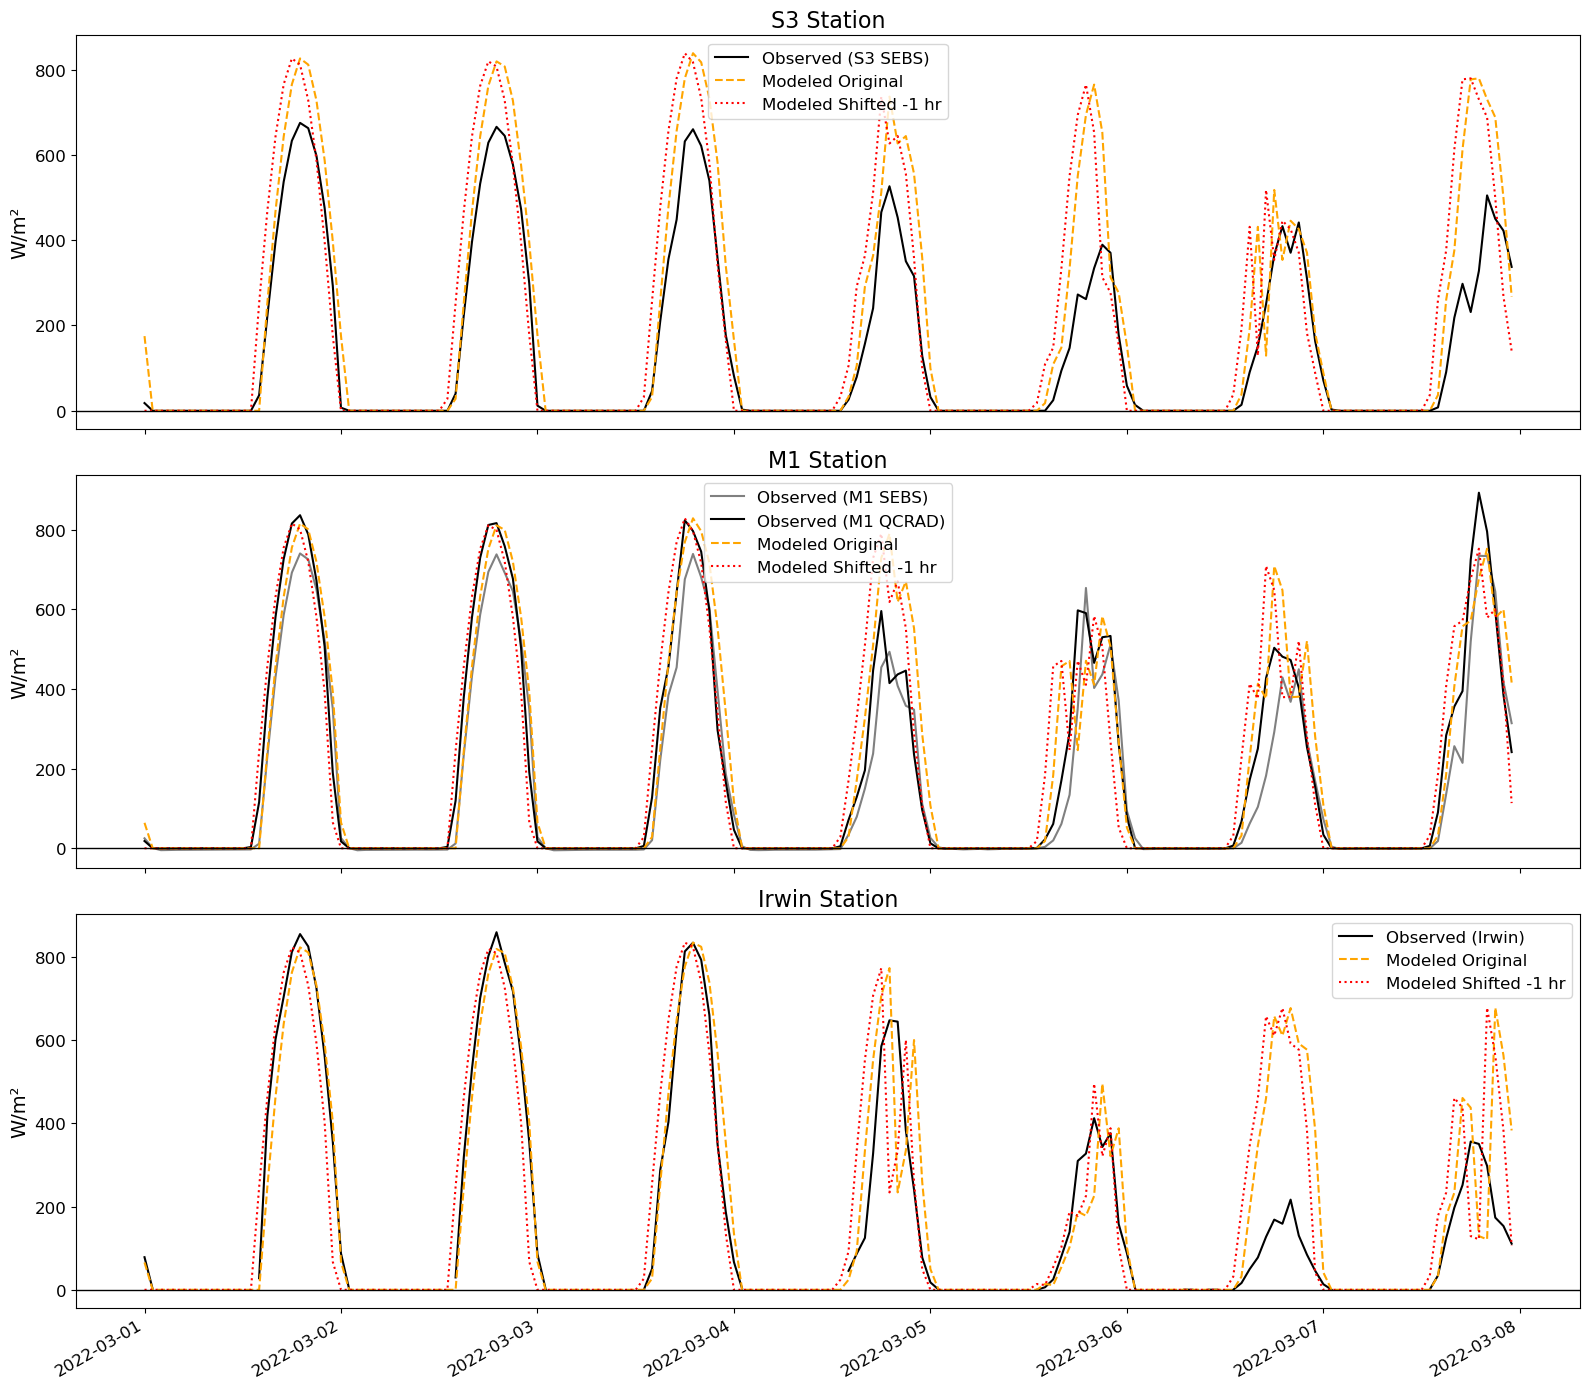

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Define March 1–7, 2022 time range
march_start = '2022-03-01 00:00'
march_end = '2022-03-07 23:00'

# Shift modeled data by -1 hour (1 hour backward)
m1_dsw3_shifted = m1_dsw3.copy()
m1_dsw3_shifted['time'] = m1_dsw3_shifted['time'] - pd.Timedelta(hours=1)

s3_dsw3_shifted = s3_dsw3.copy()
s3_dsw3_shifted['time'] = s3_dsw3_shifted['time'] - pd.Timedelta(hours=1)

irwin_dsw3_shifted = irwin_dsw3.copy()
irwin_dsw3_shifted['time'] = irwin_dsw3_shifted['time'] - pd.Timedelta(hours=1)

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
s3_obs_hourly = s3_sw_subset[sail_var].sel(time=slice(march_start, march_end)).clip(min=0)
s3_model_hourly = s3_dsw3.sel(time=slice(march_start, march_end))
s3_model_shifted = s3_dsw3_shifted.sel(time=slice(march_start, march_end))

# ======= M1 Station =======
m1_obs_hourly = m1_sw_subset[sail_var].sel(time=slice(march_start, march_end))
sail_var2 = 'BestEstimate_down_short_hemisp'
m1qc_obs_hourly = m1qc_best_subset[sail_var2].sel(time=slice(march_start, march_end))
m1_model_hourly = m1_dsw3.sel(time=slice(march_start, march_end))
m1_model_shifted = m1_dsw3_shifted.sel(time=slice(march_start, march_end))

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_hourly = irwin_pyra_hourly.loc[march_start:march_end]
irwin_obs = irwin_hourly['VIS_IN'].where(irwin_hourly['VIS_IN'] > 0)
irwin_model_hourly = irwin_dsw3.sel(time=slice(march_start, march_end))
irwin_model_shifted = irwin_dsw3_shifted.sel(time=slice(march_start, march_end))

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 14), sharex=True)

label_size = 14
tick_size = 12
legend_size = 12

# --- S3 Plot ---
axes[0].plot(s3_obs_hourly['time'], s3_obs_hourly, label='Observed (S3 SEBS)', color='black')
axes[0].plot(s3_model_hourly['time'], s3_model_hourly['dsw3h'], label='Modeled Original', color='orange', linestyle='--')
axes[0].plot(s3_model_shifted['time'], s3_model_shifted['dsw3h'], label='Modeled Shifted -1 hr', color='red', linestyle=':')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].set_title('S3 Station', fontsize=16)
axes[0].legend(fontsize=legend_size)
axes[0].tick_params(axis='both', labelsize=tick_size)

# --- M1 Plot ---
axes[1].plot(m1_obs_hourly['time'], m1_obs_hourly, label='Observed (M1 SEBS)', color='grey')
axes[1].plot(m1qc_obs_hourly['time'], m1qc_obs_hourly, label='Observed (M1 QCRAD)', color='black')
axes[1].plot(m1_model_hourly['time'], m1_model_hourly['dsw3h'], label='Modeled Original', color='orange', linestyle='--')
axes[1].plot(m1_model_shifted['time'], m1_model_shifted['dsw3h'], label='Modeled Shifted -1 hr', color='red', linestyle=':')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].set_title('M1 Station', fontsize=16)
axes[1].legend(fontsize=legend_size)
axes[1].tick_params(axis='both', labelsize=tick_size)

# --- Irwin Plot ---
axes[2].plot(irwin_obs.index, irwin_obs, label='Observed (Irwin)', color='black')
axes[2].plot(irwin_model_hourly['time'], irwin_model_hourly['dsw3h'], label='Modeled Original', color='orange', linestyle='--')
axes[2].plot(irwin_model_shifted['time'], irwin_model_shifted['dsw3h'], label='Modeled Shifted -1 hr', color='red', linestyle=':')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].set_title('Irwin Station', fontsize=16)
axes[2].legend(fontsize=legend_size)
axes[2].tick_params(axis='both', labelsize=tick_size)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


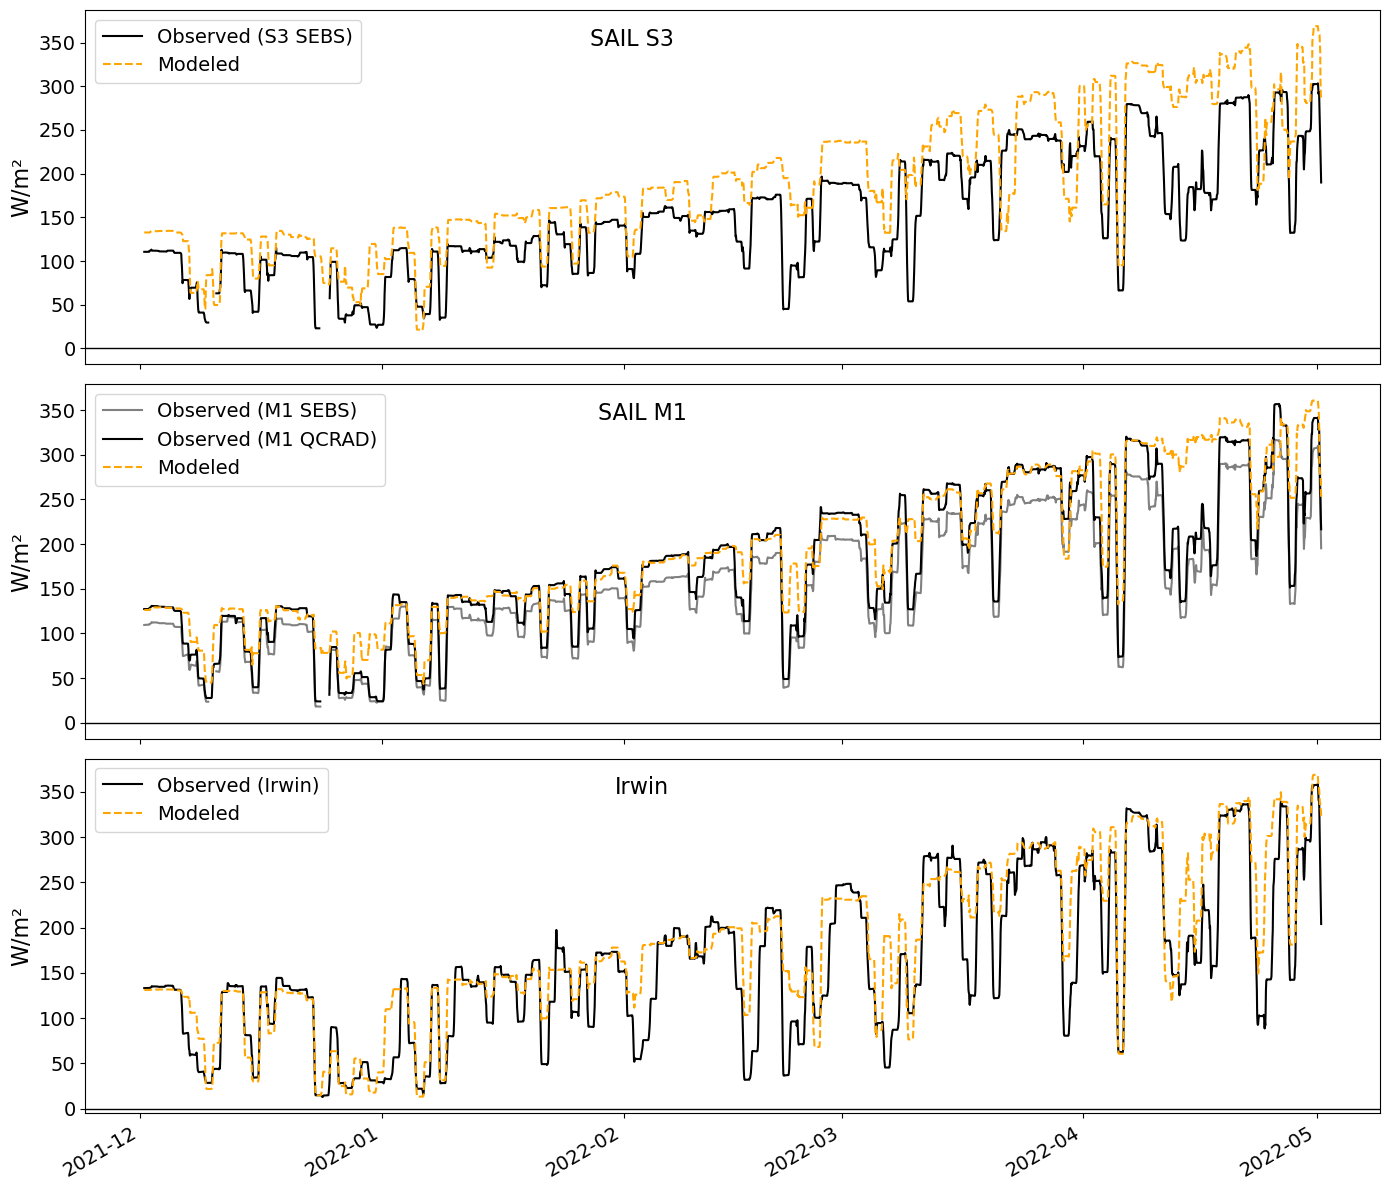

In [6]:
# FIGURE 1
import matplotlib.pyplot as plt
import pandas as pd

# Define Water Year 2022 time range (aligned to full day)
start_wy2022 = '2021-12-01 00:00'
end_wy2022   = '2022-05-01 23:00'
win = 24  # 24-hour rolling window

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
s3_obs_hourly = s3_sw_subset[sail_var].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
# s3_obs_hourly = s3_obs.resample(time='1h').mean()
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
s3_model_smoothed = s3_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()

# ======= M1 Station =======
m1_obs_hourly = m1_sw_subset[sail_var].sel(time=slice(start_wy2022, end_wy2022))
# m1_obs_hourly = m1_obs.resample(time='1h').mean()
m1_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
m1_model_smoothed = m1_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
sail_var2 = 'BestEstimate_down_short_hemisp'
m1_obs_hourly = m1qc_best_subset[sail_var2].sel(time=slice(start_wy2022, end_wy2022))
m1qc_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_hourly = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]
irwin_obs = irwin_hourly['VIS_IN'].rolling(window=win, center=True).mean()
irwin_obs = irwin_obs.where(irwin_obs > 0)
irwin_model_smoothed = irwin_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)

# Font sizes
title_size = 18
label_size = 16
tick_size = 14
legend_size = 14

# --- S3 Plot ---
axes[0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, label='Observed (S3 SEBS)', color='black')
axes[0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], label='Modeled', color='orange', linestyle='--')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].text(0.39, 0.95, 'SAIL S3', transform=axes[0].transAxes,
             fontsize=16, verticalalignment='top', horizontalalignment='left')
axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].legend(fontsize=legend_size)

# --- M1 Plot ---
axes[1].plot(m1_obs_smoothed['time'], m1_obs_smoothed, label='Observed (M1 SEBS)', color='grey')
axes[1].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, label='Observed (M1 QCRAD)', color='black')
axes[1].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], label='Modeled', color='orange', linestyle='--')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].text(0.43, 0.95, 'SAIL M1', transform=axes[1].transAxes,
             fontsize=16, va='top', ha='center')
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)
axes[1].legend(fontsize=legend_size)

# --- Irwin Plot ---
axes[2].plot(irwin_obs.index, irwin_obs, label='Observed (Irwin)', color='black')
axes[2].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], label='Modeled', color='orange', linestyle='--')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].text(0.43, 0.95, 'Irwin', transform=axes[2].transAxes,
             fontsize=16, va='top', ha='center')
axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)
axes[2].legend(fontsize=legend_size)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Optional: Save figure
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'f1-seasonal-3.png', dpi=300, bbox_inches='tight')

<xarray.Dataset> Size: 12B
Dimensions:  ()
Coordinates:
    x        float32 4B ...
    y        float32 4B ...
Data variables:
    k        float32 4B 0.9998

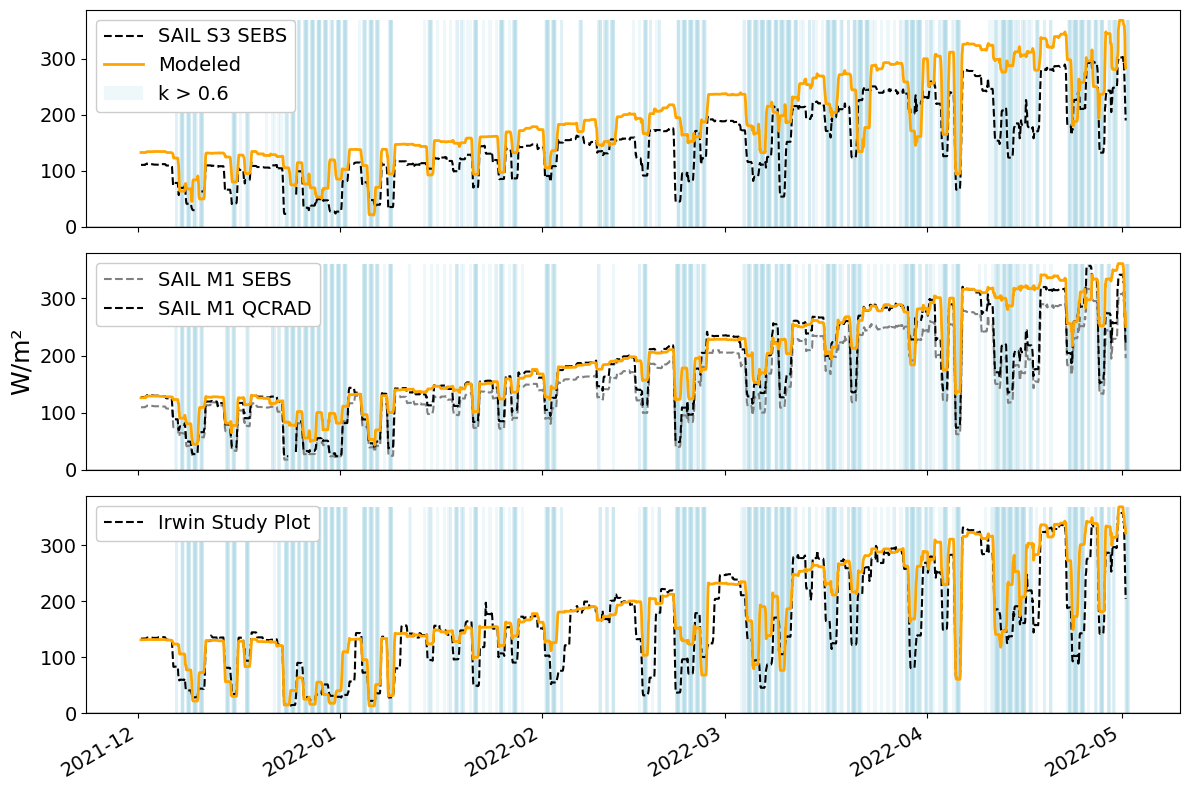

In [44]:
# FIGURE 1
import matplotlib.pyplot as plt
import pandas as pd

# Define Water Year 2022 time range (aligned to full day)
start_wy2022 = '2021-12-01 00:00'
end_wy2022   = '2022-05-01 23:00'
win = 24  # 24-hour rolling window

# ======= S3 Station =======
sail_var = 'down_short_hemisp'
s3_obs_hourly = s3_sw_subset[sail_var].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
# s3_obs_hourly = s3_obs.resample(time='1h').mean()
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
s3_model_smoothed = s3_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
s3_k_smoothed = s3_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

# ======= M1 Station =======
m1_obs_hourly = m1_sw_subset[sail_var].sel(time=slice(start_wy2022, end_wy2022))
# m1_obs_hourly = m1_obs.resample(time='1h').mean()
m1_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
m1_model_smoothed = m1_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
m1_k_smoothed = m1_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

sail_var2 = 'BestEstimate_down_short_hemisp'
m1_obs_hourly = m1qc_best_subset[sail_var2].sel(time=slice(start_wy2022, end_wy2022))
m1qc_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_hourly = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]
irwin_obs = irwin_hourly['VIS_IN'].rolling(window=win, center=True).mean()
irwin_obs = irwin_obs.where(irwin_obs > 0)
irwin_model_smoothed = irwin_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
irwin_k_smoothed = irwin_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

# ======= Plotting =======
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

# Font sizes
title_size = 18
label_size = 18
tick_size = 14
legend_size = 14

# plt.bar(obs_df.index, obs_df['storm_hour'] * obs_df['VIS_IN'].max(), width=0.1,
#             alpha=0.2, color='blue', label='Storm hours (<60% clearsky)')
lwd = 2

k_thresh = 0.6

# --- S3 Plot ---
axes[0].bar(s3_k_smoothed['time'], (s3_k_smoothed['k'] > k_thresh) * s3_model_smoothed['dsw3h'].max(), label='k > '+str(k_thresh), color='lightblue', width= 0.5, alpha=0.2)
axes[0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, label='SAIL S3 SEBS', color='black', linestyle='--')
axes[0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], label='Modeled', color='orange', linewidth=lwd)
axes[0].axhline(0, color='black', linewidth=1)
# axes[0].text(0.39, 0.95, 'SAIL S3', transform=axes[0].transAxes,
#              fontsize=16, verticalalignment='top', horizontalalignment='left')
# axes[0].set_ylabel('W/m²', fontsize=label_size)
axes[0].tick_params(axis='both', labelsize=tick_size)
axes[0].legend(fontsize=legend_size, framealpha=1, loc='upper left')

# --- M1 Plot ---
axes[1].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * m1_model_smoothed['dsw3h'].max(), label='', color='lightblue', width= 0.5, alpha=0.2)
axes[1].plot(m1_obs_smoothed['time'], m1_obs_smoothed, label='SAIL M1 SEBS', color='grey', linestyle='--')
axes[1].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, label='SAIL M1 QCRAD', color='black', linestyle='--')
axes[1].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], label='', color='orange', linewidth=lwd)
axes[1].axhline(0, color='black', linewidth=1)
# axes[1].text(0.43, 0.95, 'SAIL M1', transform=axes[1].transAxes,
#              fontsize=16, va='top', ha='center')
axes[1].set_ylabel('W/m²', fontsize=label_size)
axes[1].tick_params(axis='both', labelsize=tick_size)
axes[1].legend(fontsize=legend_size, framealpha=1, loc='upper left')

# --- Irwin Plot ---
axes[2].bar(irwin_k_smoothed['time'], (irwin_k_smoothed['k'] > k_thresh) * irwin_model_smoothed['dsw3h'].max(), label='', color='lightblue', width= 0.5, alpha=0.2)
axes[2].plot(irwin_obs.index, irwin_obs, label='Irwin Study Plot', color='black', linestyle='--')
axes[2].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], label='', color='orange', linewidth=lwd)
axes[2].axhline(0, color='black', linewidth=1)
# axes[2].text(0.43, 0.95, 'Irwin', transform=axes[2].transAxes,
#              fontsize=16, va='top', ha='center')
# axes[2].set_ylabel('W/m²', fontsize=label_size)
axes[2].tick_params(axis='both', labelsize=tick_size)
axes[2].legend(fontsize=legend_size, framealpha=1, loc='upper left')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Optional: Save figure
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-wy22-S3M1Ir-compare-k06.png', dpi=300, bbox_inches='tight')

In [46]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# # Define time range
# start = np.datetime64('2021-12-01')
# end = np.datetime64('2022-05-01')

# # Step 1: Compute bias per station
# def compute_bias_and_category(obs_da, model_ds, k_ds, station_name):
#     # Slice and convert to pandas
#     obs = obs_da.sel(time=slice(start, end)).to_series()
#     model = model_ds['dsw3h'].sel(time=slice(start, end)).to_series()
#     k = k_ds['k'].sel(time=slice(start, end)).to_series()

#     # Combine and align
#     df = pd.concat([obs, model, k], axis=1, keys=['obs', 'model', 'k']).dropna()

#     # Compute bias and category
#     df['bias'] = df['model'] - df['obs']
#     df['category'] = np.where(df['k'] < 0.8, 'Clear', 'Cloudy')
#     df['station'] = station_name

#     return df[['station', 'bias', 'category']]

# # S3 and M1 from xarray
# s3_df = compute_bias_and_category(s3_obs_hourly, s3_dsw3, s3_k, 'SAIL S3')
# m1_df = compute_bias_and_category(m1_obs_hourly, m1_dsw3, m1_k, 'SAIL M1 QCRAD')

# # Irwin from pandas
# irwin_df = pd.DataFrame({
#     'obs': irwin_obs.loc[start:end],
#     'model': irwin_dsw3['dsw3h'].sel(time=slice(start, end)).to_series(),
#     'k': irwin_k['k'].sel(time=slice(start, end)).to_series()
# }).dropna()

# irwin_df['bias'] = irwin_df['model'] - irwin_df['obs']
# irwin_df['category'] = np.where(irwin_df['k'] < 0.6, 'Clear', 'Cloudy')
# irwin_df['station'] = 'Irwin Study Plot'
# irwin_df = irwin_df[['station', 'bias', 'category']]

# # Combine all
# combined_df = pd.concat([s3_df, m1_df, irwin_df])

# # Step 2: Plot
# plt.figure(figsize=(10, 6))
# # sns.violinplot(data=combined_df, x='station', y='bias', hue='category',
# #                palette={'Clear': 'lightblue', 'Cloudy': 'grey'}, split=True)
# sns.violinplot(data=combined_df, x='station', y='bias', hue='category',
#                palette={'Clear': 'lightblue', 'Cloudy': 'grey'},
#                dodge=True, split=False)
# plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

# plt.title("Bias Distribution by Station and Sky Condition")
# plt.ylabel("Bias (Model - Observation) [W/m²]")
# plt.xlabel("Station")
# plt.legend(title="Sky Condition")
# # plt.grid(True)
# plt.tight_layout()
# plt.show()


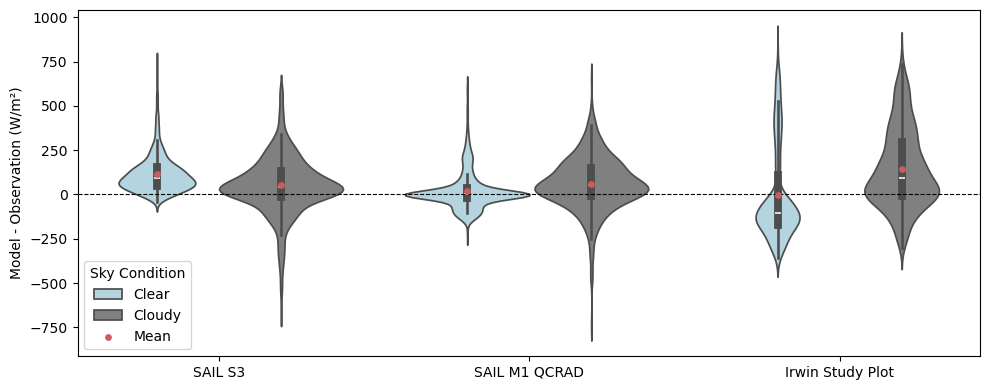

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define time range
start = np.datetime64('2021-12-01')
end = np.datetime64('2022-05-01')

k_thresh = 0.6

# Step 1: Compute bias per station
def compute_bias_and_category(obs_da, model_ds, k_ds, station_name):
    # Slice and convert to pandas
    obs = obs_da.sel(time=slice(start, end)).to_series()
    obs[obs <= 0] = np.nan  # Treat 0 or negative obs as missing
    model = model_ds['dsw3h'].sel(time=slice(start, end)).to_series()
    k = k_ds['k'].sel(time=slice(start, end)).to_series()

    # Combine and align
    df = pd.concat([obs, model, k], axis=1, keys=['obs', 'model', 'k']).dropna()

    # Compute bias and category
    df['bias'] = df['model'] - df['obs']
    df['category'] = np.where(df['k'] < k_thresh, 'Clear', 'Cloudy')
    df['station'] = station_name

    return df[['station', 'bias', 'category']]

# S3 and M1 from xarray
s3_df = compute_bias_and_category(s3_obs_hourly, s3_dsw3, s3_k, 'SAIL S3')
m1_df = compute_bias_and_category(m1_obs_hourly, m1_dsw3, m1_k, 'SAIL M1 QCRAD')

# Irwin from pandas
irwin_obs_clipped = irwin_obs.loc[start:end].copy()
irwin_obs_clipped[irwin_obs_clipped <= 0] = np.nan  # Set zero or negative to NaN

irwin_df = pd.DataFrame({
    'obs': irwin_obs_clipped,
    'model': irwin_dsw3['dsw3h'].sel(time=slice(start, end)).to_series(),
    'k': irwin_k['k'].sel(time=slice(start, end)).to_series()
}).dropna()

irwin_df['bias'] = irwin_df['model'] - irwin_df['obs']
irwin_df['category'] = np.where(irwin_df['k'] < k_thresh, 'Clear', 'Cloudy')
irwin_df['station'] = 'Irwin Study Plot'
irwin_df = irwin_df[['station', 'bias', 'category']]

# Combine all
combined_df = pd.concat([s3_df, m1_df, irwin_df])

# Step 2: Plot
plt.figure(figsize=(10, 4))
sns.violinplot(data=combined_df, x='station', y='bias', hue='category',
               palette={'Clear': 'lightblue', 'Cloudy': 'grey'},
               dodge=True, split=False)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)


# Mean dot overlay
group_means = combined_df.groupby(['station', 'category'])['bias'].mean().reset_index()
ax = plt.gca()
x_positions = {}
for i, station in enumerate(combined_df['station'].unique()):
    x_positions[(station, 'Clear')] = i - 0.2
    x_positions[(station, 'Cloudy')] = i + 0.2

for i, row in group_means.iterrows():
    x = x_positions[(row['station'], row['category'])]
    y = row['bias']
    ax.scatter(x, y, color='indianred', s=15, zorder=5, label='Mean' if i == 0 else "")

# plt.title("Bias Distribution by Station and Sky Condition")
plt.ylabel("Model - Observation (W/m²)")
plt.xlabel("")
# plt.legend(title="Sky Condition (k > "+str(k_thresh)+")")
plt.legend(title="Sky Condition")
plt.tight_layout()
plt.show()

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'fig-wy22-cloudy_k06.png', dpi=300, bbox_inches='tight')

/scratch/local/u1037042/4977420/ipykernel_2113426/2439834832.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=s3_df, x='category', y='bias',
/scratch/local/u1037042/4977420/ipykernel_2113426/2439834832.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend().remove()
/scratch/local/u1037042/4977420/ipykernel_2113426/2439834832.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_df, x='category', y='bias',
/scratch/local/u1037042/4977420/ipykernel_2113426/2439834832.py:94: UserWarning: No artists with labels found to put in leg

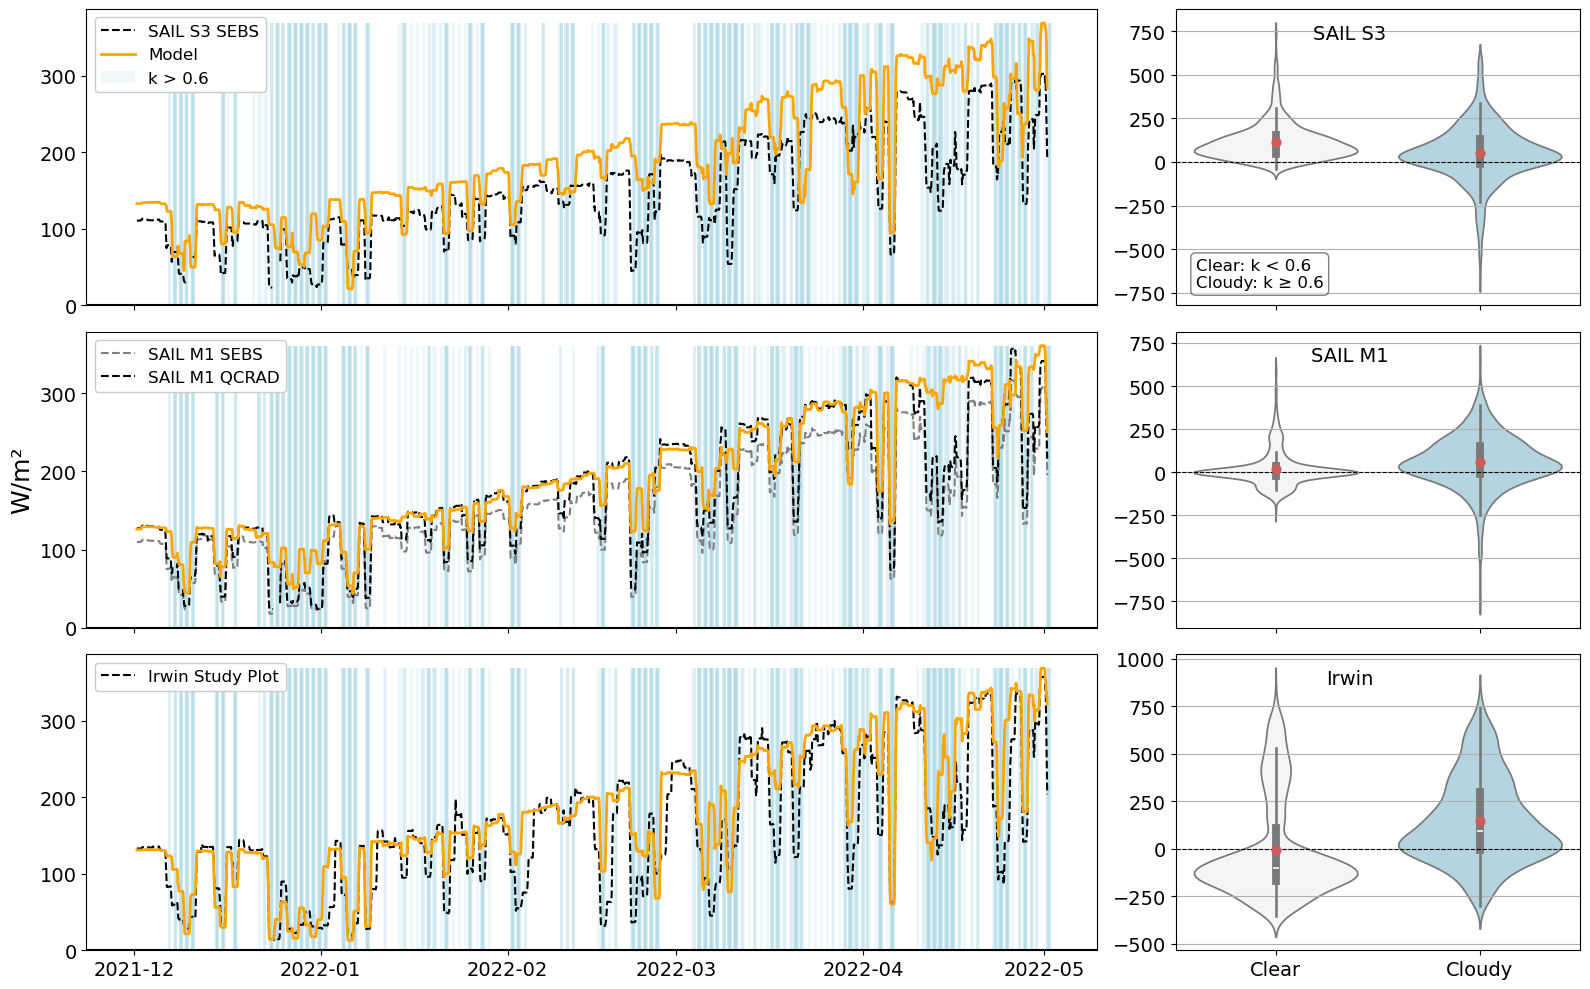

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid: 3 rows (S3, M1, Irwin), 2 cols (timeseries | violin)
# fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 10), sharex=False,
#                          gridspec_kw={'width_ratios': [3, 1]})

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(16, 10),
    sharex='col', #sharey='row',
    gridspec_kw={'width_ratios': [3, 1]}
)


# Font sizes
tick_size = 14
legend_size = 12
label_size = 18
lwd = 2
k_thresh = 0.6

# ==== Row 0: S3 ====
# -- Time Series --
axes[0, 0].bar(s3_k_smoothed['time'], (s3_k_smoothed['k'] > k_thresh) * s3_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.2, label='k > 0.6')
axes[0, 0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, color='black', linestyle='--', label='SAIL S3 SEBS')
axes[0, 0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='Model')
axes[0, 0].axhline(0, color='black')
axes[0, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[0, 0].set_ylabel('W/m²', fontsize=label_size)
axes[0, 0].tick_params(labelsize=tick_size)

# -- Violin Plot --
sns.violinplot(data=s3_df, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[0, 1])
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].grid(True, axis='y')
axes[0, 1].legend().remove()
axes[0, 1].tick_params(labelsize=tick_size)
axes[0, 1].text(0.43, 0.95, 'SAIL S3', transform=axes[0,1].transAxes,
             fontsize=14, va='top', ha='center')

# Add mean bias dot
s3_means = s3_df.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[0, 1].scatter(i, s3_means[cat], color='indianred', zorder=5, s=40)


# Text and box properties
textstr = "Clear: k < 0.6\nCloudy: k ≥ 0.6"
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')

# Place it in bottom-left
axes[0, 1].text(
    0.05, 0.05, textstr,
    # transform=ax.transAxes,
    transform=axes[0,1].transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=props
)





# ==== Row 1: M1 ====
axes[1, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * m1_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.2)
axes[1, 0].plot(m1_obs_smoothed['time'], m1_obs_smoothed, linestyle='--', color='grey', label='SAIL M1 SEBS')
axes[1, 0].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, linestyle='--', color='black', label='SAIL M1 QCRAD')
axes[1, 0].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[1, 0].axhline(0, color='black')
axes[1, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[1, 0].set_ylabel('W/m²', fontsize=label_size)
axes[1, 0].tick_params(labelsize=tick_size)


# sns.violinplot(data=m1_df, x='station', y='bias', hue='category',
#                palette={'Clear': 'lightblue', 'Cloudy': 'grey'},
#                dodge=True, split=False, ax=axes[1, 1])
sns.violinplot(data=m1_df, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[1, 1])

axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].grid(True, axis='y')
axes[1, 1].legend().remove()
axes[1, 1].tick_params(labelsize=tick_size)
axes[1, 1].text(0.43, 0.95, 'SAIL M1', transform=axes[1,1].transAxes,
             fontsize=14, va='top', ha='center')

m1_means = m1_df.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[1, 1].scatter(i, m1_means[cat], color='indianred', zorder=5, s=40)

# ==== Row 2: Irwin ====
axes[2, 0].bar(irwin_k_smoothed['time'], (irwin_k_smoothed['k'] > k_thresh) * irwin_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.2)
axes[2, 0].plot(irwin_obs.index, irwin_obs, linestyle='--', color='black', label='Irwin Study Plot')
axes[2, 0].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[2, 0].axhline(0, color='black')
axes[2, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[2, 0].set_ylabel('W/m²', fontsize=label_size)
axes[2, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=irwin_df, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[2, 1])

axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2, 1].set_ylabel("")
axes[2, 1].set_xlabel("")
axes[2, 1].grid(True, axis='y')

axes[2, 1].legend().remove()
axes[2, 1].tick_params(labelsize=tick_size)
axes[2, 1].text(0.43, 0.95, 'Irwin', transform=axes[2,1].transAxes,
             fontsize=14, va='top', ha='center')

irwin_means = irwin_df.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[2, 1].scatter(i, irwin_means[cat], color='indianred', zorder=5, s=40)

# Final layout
plt.tight_layout()
# plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
plt.savefig(svpth + 'fig-wy22-combined.png', dpi=300, bbox_inches='tight')

AttributeError: module 'matplotlib.patches' has no attribute 'Line2D'

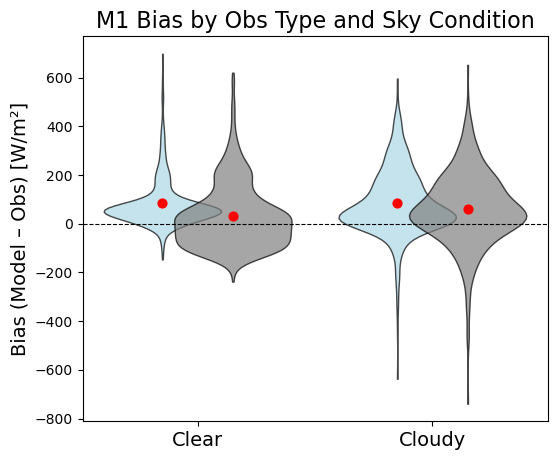

In [53]:
import pandas as pd
import numpy as np

# Slice time range (same as before)
start = np.datetime64('2021-12-01')
end = np.datetime64('2022-05-01')

sail_var = 'down_short_hemisp'
m1_obs_hourly1 = m1_sw_subset[sail_var].sel(time=slice(start_wy2022, end_wy2022))
sail_var2 = 'BestEstimate_down_short_hemisp'
m1_obs_hourly2 = m1qc_best_subset[sail_var2].sel(time=slice(start_wy2022, end_wy2022))


# Get time-sliced series (xarray → pandas Series)
obs1 = m1_obs_hourly1.sel(time=slice(start, end)).to_series()
obs1[obs1 <= 0] = np.nan
obs2 = m1_obs_hourly2.sel(time=slice(start, end)).to_series()
obs2[obs2 <= 0] = np.nan

model = m1_dsw3['dsw3h'].sel(time=slice(start, end)).to_series()
k = m1_k['k'].sel(time=slice(start, end)).to_series()

# Align all
df = pd.concat([obs1, obs2, model, k], axis=1, keys=['obs_SEBS', 'obs_QCRAD', 'model', 'k']).dropna()

# Compute bias and category
df_long = pd.DataFrame({
    'bias': np.concatenate([
        df['model'] - df['obs_SEBS'],
        df['model'] - df['obs_QCRAD']
    ]),
    'category': np.concatenate([
        np.where(df['k'] < 0.6, 'Clear', 'Cloudy'),
        np.where(df['k'] < 0.6, 'Clear', 'Cloudy')
    ]),
    'obs_type': ['SEBS'] * len(df) + ['QCRAD'] * len(df)
})

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

# Prepare data arrays
cats = ['Clear', 'Cloudy']
offsets = [-0.15, 0.15]  # offset left, offset right

for obs_i, label, color, offset in zip(
    ['SEBS', 'QCRAD'],
    ['SEBS', 'QCRAD'],
    ['lightblue', 'grey'],
    offsets
):
    parts = ax.violinplot(
        [df_long.loc[(df_long['category'] == cat) & (df_long['obs_type'] == obs_i), 'bias']
         for cat in cats],
        positions=[i + offset for i in range(len(cats))],
        showmeans=False, showmedians=False, showextrema=False
    )
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

# Add mean dots
means = df_long.groupby(['category', 'obs_type'])['bias'].mean()
for i, cat in enumerate(cats):
    for obs_i, label, offset in zip(['SEBS', 'QCRAD'], ['SEBS', 'QCRAD'], offsets):
        mean_bias = means[(cat, obs_i)]
        ax.scatter(i + offset, mean_bias, color='red', s=40, zorder=5)

# Customize axis
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, fontsize=14)
ax.set_title('M1 Bias by Obs Type and Sky Condition', fontsize=16)
ax.set_ylabel('Bias (Model – Obs) [W/m²]', fontsize=14)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

# Add custom legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='lightblue', label='SEBS'),
    mpatches.Patch(color='grey', label='QCRAD'),
    mpatches.Line2D([], [], marker='o', color='red', linestyle='None', label='Mean Bias')
]
ax.legend(handles=legend_handles, fontsize=12)

plt.tight_layout()
plt.show()


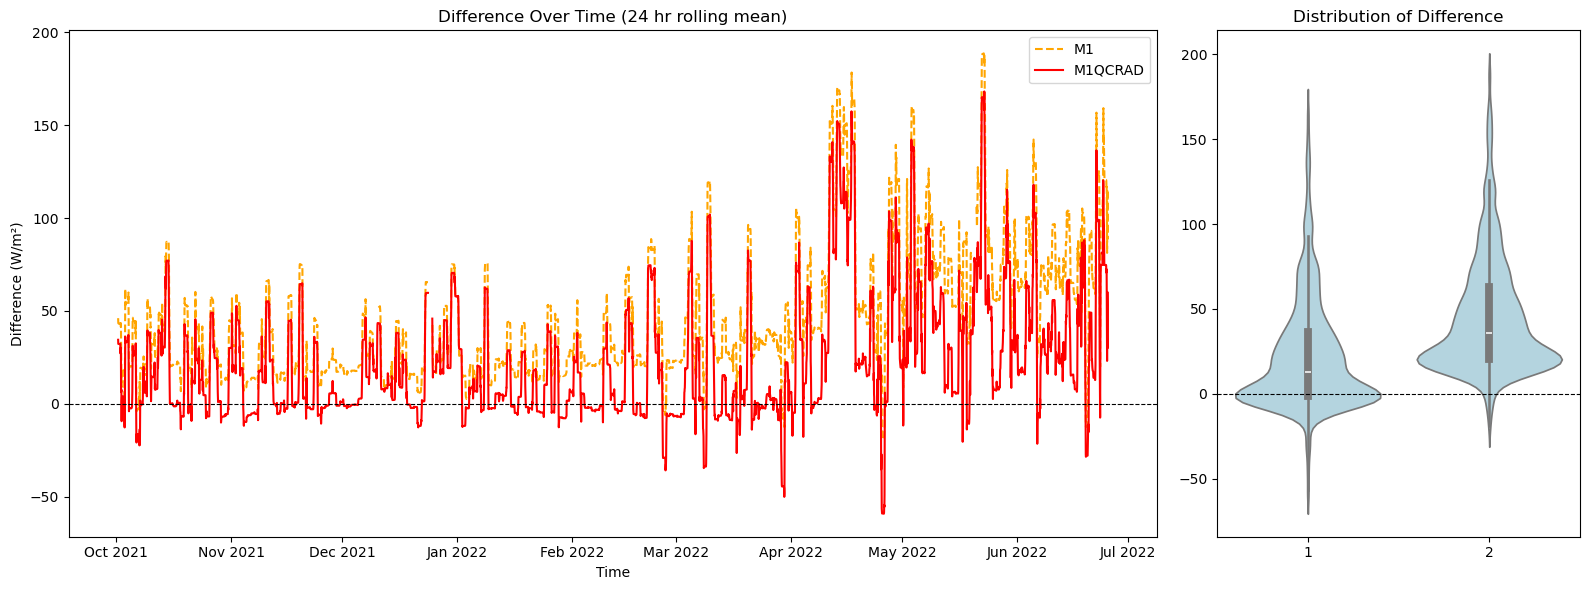

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# 1. Compute the difference (DIR + DIF - SW)
sw_diff_m1 = m1_model_smoothed - m1_obs_smoothed
sw_diff_m1qc = m1_model_smoothed - m1qc_obs_smoothed
sw_diff_s3 = s3_model_smoothed - s3_obs_smoothed
# sw_diff_irwin = irwin_model_smoothed - irwin_obs
sw_diff_irwin = irwin_model_smoothed.to_dataframe()['dsw3h'] - irwin_obs

# 2. Set up 1-row, 2-column figure
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})

# ---- Left panel: Time series ----
ax1.plot(sw_diff_m1.time, sw_diff_m1['dsw3h'], label='M1', color='orange', linestyle="--")
ax1.plot(sw_diff_m1qc.time, sw_diff_m1qc['dsw3h'], label='M1QCRAD', color='red')
# ax1.plot(sw_diff_s3.time, sw_diff_m1['dsw3h'], label='S3', color='blue')
# ax1.plot(sw_diff_irwin.index, sw_diff_irwin, label='S3', color='green')

# ax1.plot(sw_diff2.time, sw_diff, label='(DIF + DIR) - SW', color='green')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title("Difference Over Time (24 hr rolling mean)")
ax1.set_ylabel("Difference (W/m²)")
ax1.set_xlabel("Time")
ax1.legend()
# ax1.grid(True)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# ---- Right panel: Violin plot ----
# Convert to Pandas for Seaborn
sw_diff_df = sw_diff_m1qc['dsw3h'].to_dataframe(name="diff").dropna()
sw_diff_df2 = sw_diff_m1['dsw3h'].to_dataframe(name="diff").dropna()

sns.violinplot(y="diff", data=sw_diff_df, x = 1, ax=ax2, color="lightblue", inner="box")
sns.violinplot(y="diff", data=sw_diff_df2, x = 2, ax=ax2, color="lightblue", inner="box")

ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title("Distribution of Difference")
ax2.set_ylabel("")

# Tight layout and show
plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_diff.png', dpi=300, bbox_inches='tight')

In [29]:
subset_best_hourly
s3_sw_subset

<xarray.Dataset> Size: 79kB
Dimensions:            (time: 6552)
Coordinates:
  * time               (time) datetime64[ns] 52kB 2021-10-01 ... 2022-06-30T2...
Data variables:
    down_short_hemisp  (time) float32 26kB ...

<xarray.Dataset> Size: 146kB
Dimensions:                  (time: 7320)
Coordinates:
  * time                     (time) datetime64[ns] 59kB 2021-09-30T06:00:00 ....
    x                        float32 4B 3.278e+05
    y                        float32 4B 4.314e+06
Data variables:
    bias                     (time) float32 29kB 0.5675 -0.03604 ... 0.3448
    normalized_bias          (time) float32 29kB -1.0 -1.0 -1.0 ... -1.0 -1.0
    normalized_bias_percent  (time) float32 29kB -100.0 -100.0 ... -100.0 -100.0


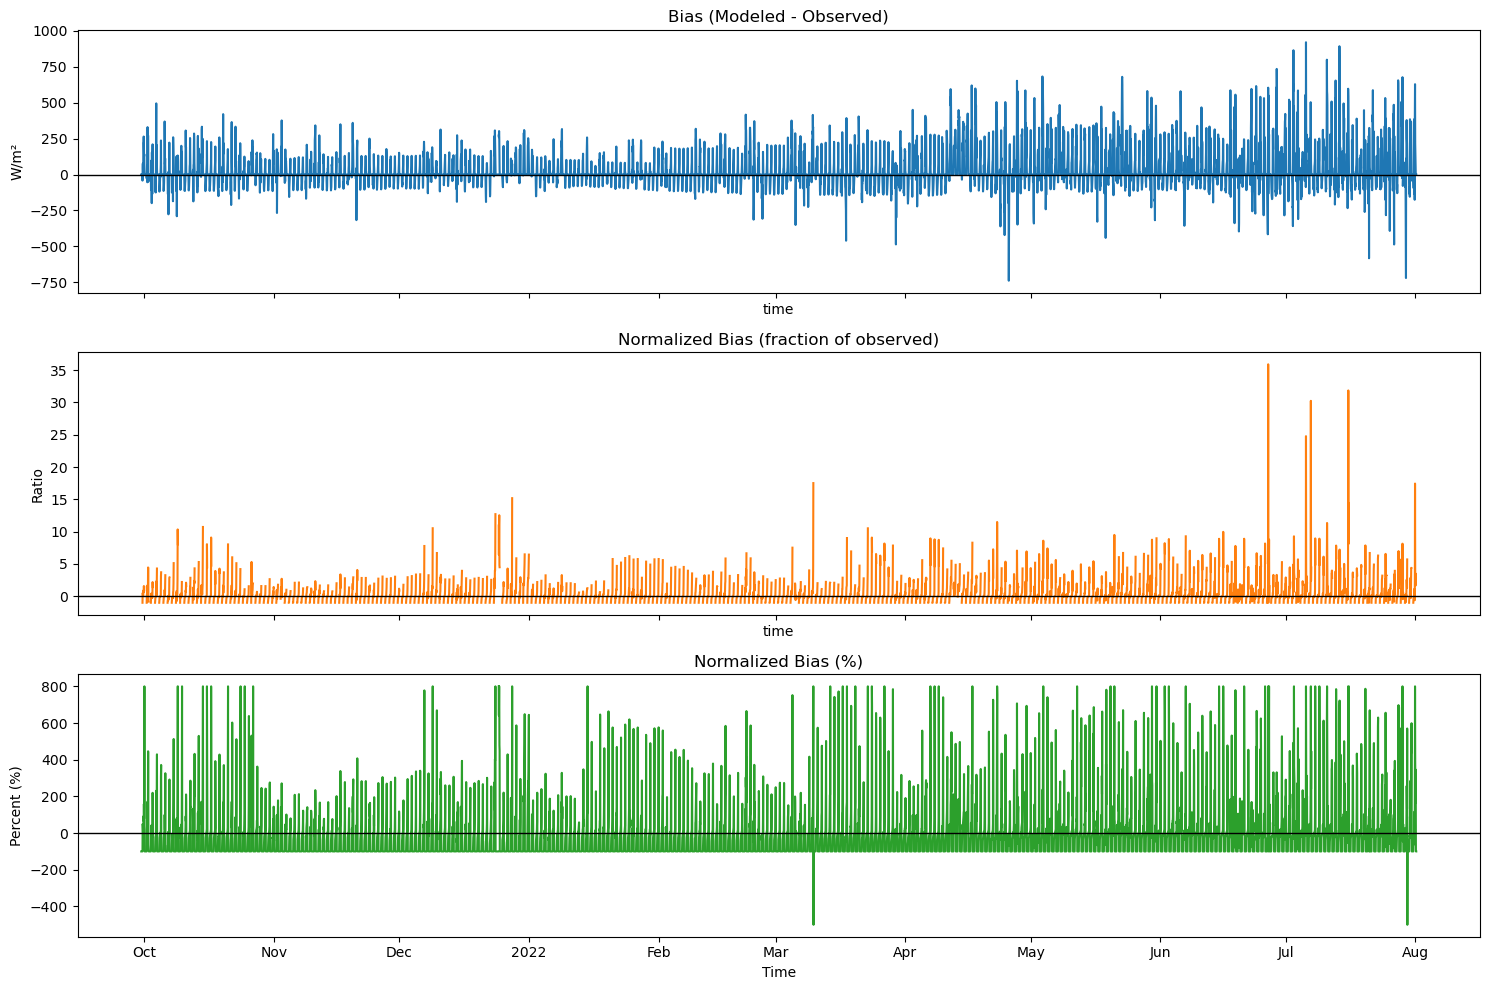

In [52]:
import xarray as xr

# Assume these are already loaded:
# modeled_ds: contains variable 'm1_dsw3'
# observed_ds: contains variable 'subset_best_hourly'

# Extract variables
m1_mod = m1_dsw3['dsw3h']
m1_obs = subset_best_hourly['BestEstimate_down_short_hemisp']

# m1_mod = s3_dsw3['dsw3h']
# m1_obs = s3_sw_subset['down_short_hemisp']

# Align the two datasets on common coordinates (e.g., time, lat, lon)
modeled_aligned, observed_aligned = xr.align(m1_mod, m1_obs, join='inner')

# Compute bias
bias = modeled_aligned - observed_aligned

# Avoid divide-by-zero: add small epsilon
epsilon = 1e-6
normalized_bias = bias / (observed_aligned + epsilon)

# Convert to percentage (optional)
normalized_bias_percent = normalized_bias * 100

# Combine into a new Dataset
results_ds = xr.Dataset({
    'bias': bias,
    'normalized_bias': normalized_bias.clip(min=-25, max=25),
    'normalized_bias_percent': normalized_bias_percent.clip(min=-500, max=800)
})

# Optional: print or save
print(results_ds)
# results_ds.to_netcdf('normalized_bias.nc')  # Save to file if needed

# Compute symmetric normalized bias
symmetric_normalized_bias = (modeled_aligned - observed_aligned) / ((modeled_aligned + observed_aligned) / 2 + epsilon)
symmetric_normalized_bias = (modeled_aligned - observed_aligned) / ((modeled_aligned + observed_aligned))

# Optional: in percentage
symmetric_normalized_bias_percent = symmetric_normalized_bias * 100

# Add to dataset
results_ds['symmetric_normalized_bias'] = symmetric_normalized_bias.clip(min=-5, max=5)
results_ds['symmetric_normalized_bias_percent'] = symmetric_normalized_bias_percent

fractional_bias = 2 * (modeled_aligned - observed_aligned) / (modeled_aligned + observed_aligned + epsilon)

results_ds['fractional_bias'] = fractional_bias.clip(min=-5, max=5)


threshold = 2  # or whatever makes sense based on your data
valid = observed_aligned > threshold

relative_bias = ((modeled_aligned - observed_aligned) / (observed_aligned + epsilon)).where(valid)
results_ds['relative_bias'] = relative_bias



import matplotlib.pyplot as plt

# Optional: Select a single location (if spatial dimensions exist)
# For example, if your data has lat/lon:
# results_ds = results_ds.sel(lat=..., lon=...)  # Use .isel(...) for index-based

# Plot setup
fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot 1: Raw Bias
results_ds['bias'].plot(ax=axs[0], color='tab:blue')
axs[0].axhline(y=0, color='black', linewidth=1)
axs[0].set_title('Bias (Modeled - Observed)')
axs[0].set_ylabel('W/m²')

# Plot 2: Normalized Bias
results_ds['relative_bias'].plot(ax=axs[1], color='tab:orange')
axs[1].axhline(y=0, color='black', linewidth=1)
axs[1].set_title('Normalized Bias (fraction of observed)')
axs[1].set_ylabel('Ratio')
# results_ds['fractional_bias'].plot(ax=axs[1], color='tab:purple')
# axs[1].set_title('Symmetric Normalized Bias (signed, bounded)')
# axs[1].set_ylabel('Ratio')

# Plot 3: Normalized Bias (%)
results_ds['normalized_bias_percent'].plot(ax=axs[2], color='tab:green')
axs[2].axhline(y=0, color='black', linewidth=1)
axs[2].set_title('Normalized Bias (%)')
axs[2].set_ylabel('Percent (%)')
axs[2].set_xlabel('Time')

# Layout
plt.tight_layout()
plt.show()


ValueError: the first argument to .rolling must be a dictionary

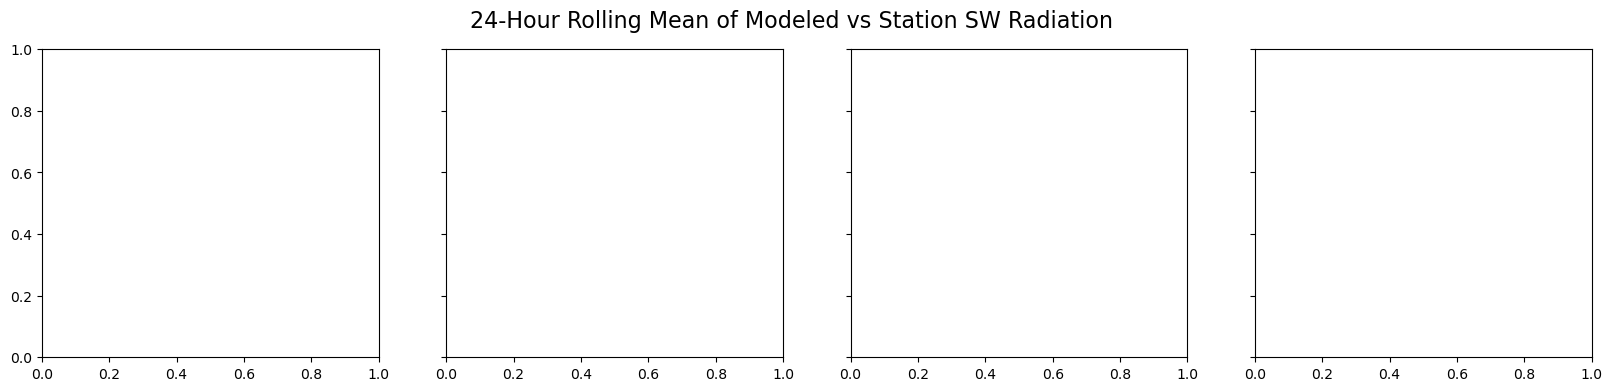

In [33]:
import matplotlib.pyplot as plt

# Set up 4-column, 1-row figure
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
fig.suptitle('24-Hour Rolling Mean of Modeled vs Station SW Radiation', fontsize=16)

# Define plot config as tuples: (ax, station_name, station_SW, modeled_SW_DataSet_or_DataArray)
plots = [
    (axes[0], 'Irwin', irwin_dsw3_subset, irwin_sw_subset),  # both are pandas
    (axes[1], 'M1', m1_dsw3_subset, m1_sw_subset['down_short_hemisp']),  
    # (axes[1], 'M1', m1_dsw3_subset, m1qc_best_subset['BestEstimate_down_short_hemisp']), 
    (axes[2], 'S3', s3_dsw3_subset, s3_sw_subset['down_short_hemisp']),
    (axes[3], 'SOS', sos_dsw3_subset, sos_sw_subset),
]

# Plot each panel
for ax, name, station, modeled in plots:
    # Ensure all are pandas Series for rolling ops
    if isinstance(station, xr.DataArray):
        station = station.to_series()
    if isinstance(modeled, xr.DataArray):
        modeled = modeled.to_series()
    
    station_rolling = station.rolling('24H', center=True).mean()
    modeled_rolling = modeled.rolling('24H', center=True).mean()
    
    ax.plot(station_rolling.index, station_rolling, label='Station SW', color='black')
    ax.plot(modeled_rolling.index, modeled_rolling, label='Modeled SW', color='orange')
    ax.set_title(name)
    ax.set_xlabel('Time')
    ax.grid(True)

axes[0].set_ylabel('SW Radiation (W/m²)')
axes[-1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


KeyError: "Window dimensions ('window',) not found in Dataset dimensions ('time',)"

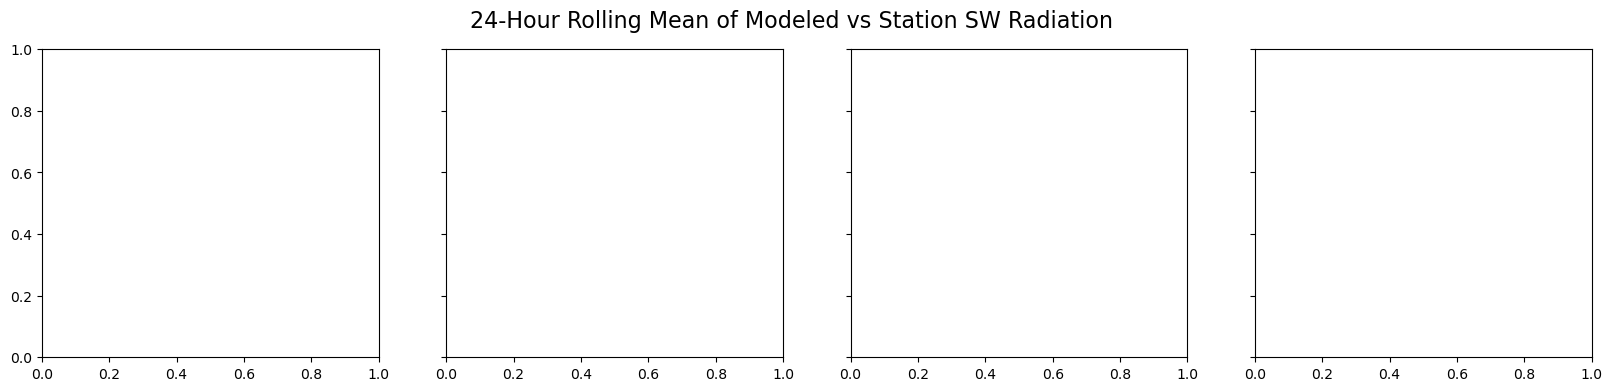

In [61]:
import matplotlib.pyplot as plt

# Set up 4-column, 1-row figure
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
fig.suptitle('24-Hour Rolling Mean of Modeled vs Station SW Radiation', fontsize=16)

# Define plot config as tuples: (ax, name, station_SW, modeled_SW)
plots = [
    (axes[0], 'Irwin', irwin_sw_subset['VIS_IN'], irwin_dsw3_subset),  # Irwin: DataFrame column and DataArray
    (axes[1], 'M1', m1_sw_subset['down_short_hemisp'], m1_dsw3_subset),
    (axes[2], 'S3', s3_sw_subset['down_short_hemisp'], s3_dsw3_subset),
    (axes[3], 'SOS', sos_sw_subset, sos_dsw3_subset),
]

# Plot each panel
for ax, name, station, modeled in plots:
    # Convert to Series if xarray
    if isinstance(station, xr.DataArray):
        station = station.to_series()
    if isinstance(modeled, xr.DataArray):
        modeled = modeled.to_series()

    # Apply 24-sample (hourly) rolling mean
    station_rolling = station.rolling(window=24, center=True).mean()
    modeled_rolling = modeled.rolling(window=24, center=True).mean()

    # Plot
    ax.plot(station_rolling.index, station_rolling, label='Station SW', color='black')
    ax.plot(modeled_rolling.index, modeled_rolling, label='Modeled SW', color='orange')
    ax.set_title(name)
    ax.set_xlabel('Time')
    ax.grid(True)

axes[0].set_ylabel('SW Radiation (W/m²)')
axes[-1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:

win = 24

# Subset and load
subset_sw_rolling = subset_sw_hourly.rolling(time=win, center=True).mean()
subset_dif_rolling = subset_dif_hourly.rolling(time=win, center=True).mean()
subset_dir_rolling = sub_dirh_hourly.rolling(time=win, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
# ax.plot(subset_sw_hourly.time, subset_sw_hourly, label='SW (raw)', color='lightgray', alpha=0.5)
ax.plot(subset_sw_rolling.time, subset_sw_rolling, label='SW (24h rolling mean)', color='green')
ax.plot(subset_dir_rolling.time, subset_dir_rolling, label='DIR horizontal)', color='orange')
ax.plot(subset_dif_rolling.time, subset_dif_rolling, label='DIF horizontal', color='yellow')
# ax.plot(subset_dif_rolling2.time, subset_dif_rolling2, label='DIF horizontal', color='yellow', linestyle="--")
ax.plot(subset_dif_rolling.time, subset_dif_rolling+subset_dir_rolling, label='SW (DIR+DIF)', color='black', linestyle="--")
# ax.plot(subset_dif_rolling2.time, subset_dif_rolling2+subset_dir_rolling, label='SW2 (DIR+DIF)', color='grey', linestyle="--")

# Formatting
ax.set_title('HRRR Radiation at M1 QCRAD')
ax.set_xlabel('Time')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend()
# ax.grid(True)

# Better x-axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'm1_qcrad_sw_components.png', dpi=300, bbox_inches='tight')

In [74]:
irwin_obs_roll.index
irwin_mod_roll.time
sos_sw_subset['Rsw_in_uw']
irwin_obs_roll

2021-10-01 00:00:00   NaN
2021-10-01 00:15:00   NaN
2021-10-01 00:30:00   NaN
2021-10-01 00:45:00   NaN
2021-10-01 01:00:00   NaN
                       ..
2022-06-25 13:30:00   NaN
2022-06-25 13:45:00   NaN
2022-06-25 14:00:00   NaN
2022-06-25 14:15:00   NaN
2022-06-25 14:30:00   NaN
Name: VIS_IN, Length: 25691, dtype: float64

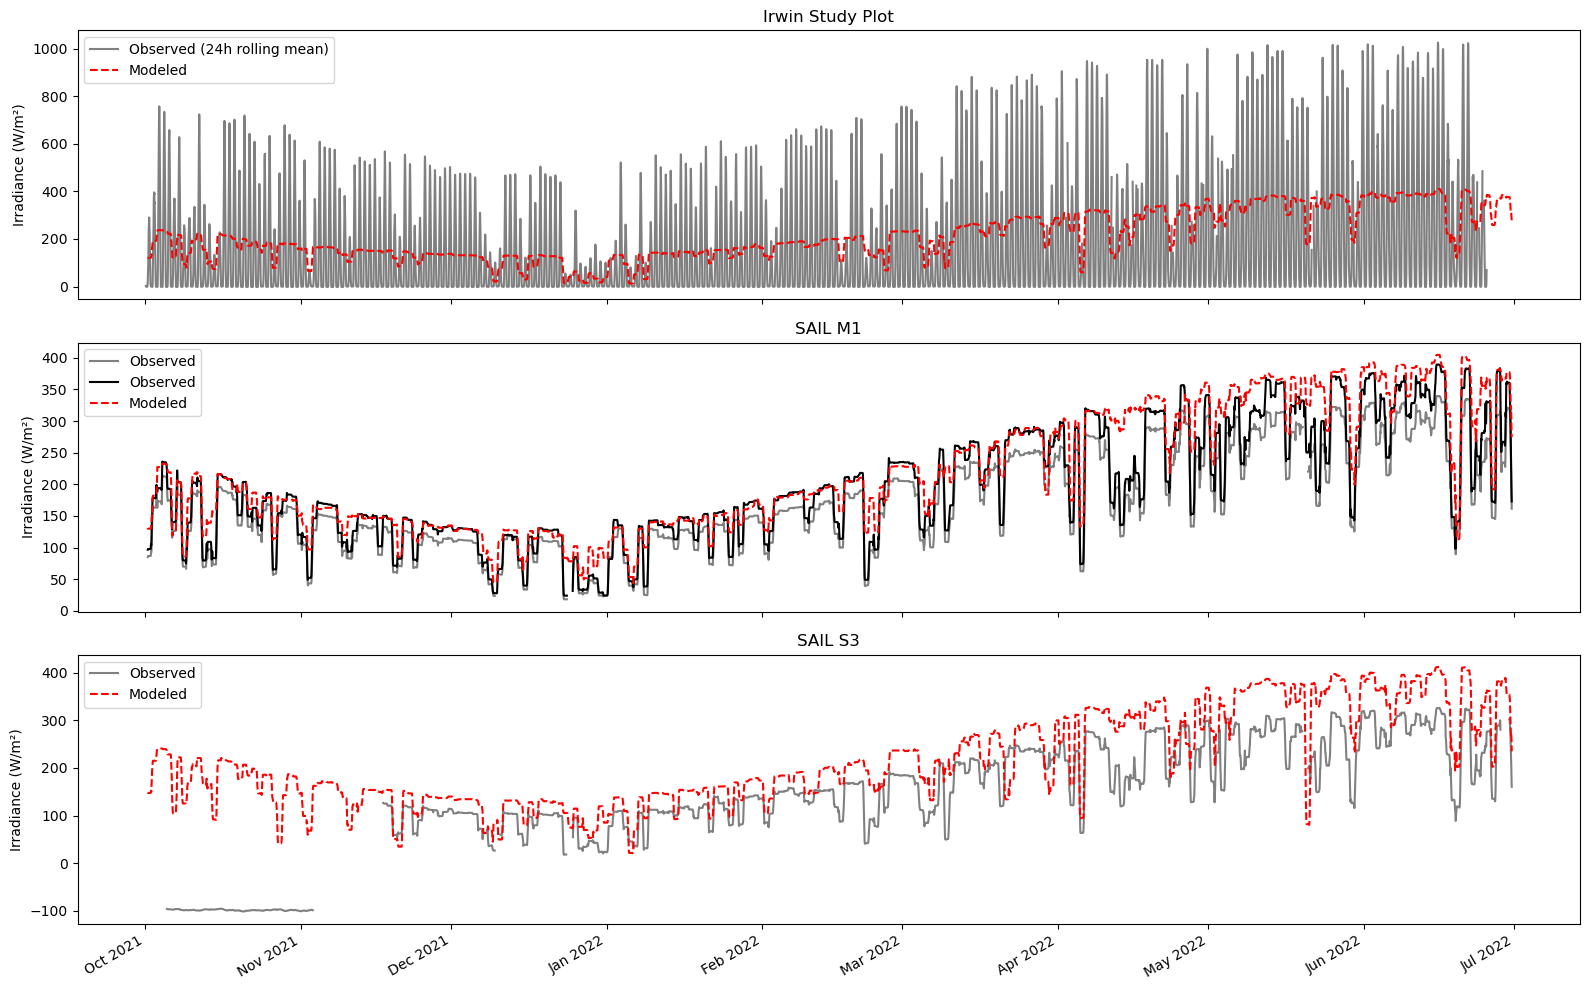

In [82]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

win = 24

# STATION
irwin_obs_roll = irwin_sw_subset['VIS_IN'].rolling(window=win, center=True).mean()
m1_obs_roll = m1_sw_subset['down_short_hemisp'].rolling(time=win, center=True).mean()
m1qc_obs_roll = m1qc_best_subset['BestEstimate_down_short_hemisp'].rolling(time=win, center=True).mean()
s3_obs_roll = s3_sw_subset['down_short_hemisp'].rolling(time=win, center=True).mean()
# sos_obs_roll = sos_sw_subset['Rsw_in_uw'].rolling(time=win, center=True).mean()

# MODELS
irwin_mod_roll = irwin_dsw3_subset['dsw3h'].rolling(time=win, center=True).mean()
m1_mod_roll = m1_dsw3_subset['dsw3h'].rolling(time=win, center=True).mean()
s3_mod_roll = s3_dsw3_subset['dsw3h'].rolling(time=win, center=True).mean()
# sos_mod_roll = sos_dsw3_subset['dsw3h'].rolling(time=win, center=True).mean()

# Set up 2-row subplot
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(16, 10), sharex=True)

# ---- IRWIN ----
ax1.plot(irwin_obs_roll.index, irwin_obs_roll, label='Observed (24h rolling mean)', color='grey')
ax1.plot(irwin_mod_roll.time, irwin_mod_roll, label='Modeled', color='red', linestyle='--')

ax1.set_title('Irwin Study Plot')
ax1.set_ylabel('Irradiance (W/m²)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# ---- Sail M1 ----
ax2.plot(m1_obs_roll.time, m1_obs_roll, label='Observed', color='grey')
ax2.plot(m1qc_obs_roll.time, m1qc_obs_roll, label='Observed', color='black')
ax2.plot(m1_mod_roll.time, m1_mod_roll, label='Modeled', color='red', linestyle='--')

ax2.set_title('SAIL M1')
ax2.set_ylabel('Irradiance (W/m²)')
ax2.legend()
# ax2.grid(True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())

# ---- SAIL S3 ----
ax3.plot(s3_obs_roll.time, s3_obs_roll, label='Observed', color='grey')
ax3.plot(s3_mod_roll.time, s3_mod_roll, label='Modeled', color='red', linestyle='--')

ax3.set_title('SAIL S3')
ax3.set_ylabel('Irradiance (W/m²)')
ax3.legend()
# ax1.grid(True)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())

# ---- SOS ----
# ax4.plot(sos_obs_roll.time, sos_obs_roll, label='Observed', color='grey')
# ax4.plot(sos_mod_roll.time, sos_mod_roll, label='Modeled', color='orange', linestyle='--')

# ax4.set_title('SOS')
# ax4.set_ylabel('Irradiance (W/m²)')
# ax2.set_xlabel('Water year 2022')
# ax4.legend()
# # ax1.grid(True)
# ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# ax4.xaxis.set_major_locator(mdates.MonthLocator())

# Final formatting
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-2025-v01/"
# plt.savefig(svpth + 'sw-comp-test01.png', dpi=300, bbox_inches='tight')